# Pipeline 

**Scaled Dataset:** DL(MLP+LSTM) <br>


# Data Preprocessing


## Importing Libraries

In [2]:
# Basic
!pip install -q kagglehub
!pip install kagglehub[pandas-datasets]

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from kagglehub import KaggleDatasetAdapter
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# PCA
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

# Metrics
from sklearn.metrics import classification_report

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

2026-04-24 21:07:30.157057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777064850.370848      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777064850.430908      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777064850.952943      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777064850.952985      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777064850.952988      55 computation_placer.cc:177] computation placer alr

## Loading Dataset

In [3]:
# Set file path (IMPORTANT: update if dataset has multiple files)
file_path = "Trojan_Detection.csv"  # e.g. "trojan.csv" OR leave empty if single file

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "subhajournal/trojan-detection",
    file_path
)

print("First 5 records:\n", df.head())

First 5 records:
    Unnamed: 0                                Flow ID    Source IP  \
0       73217    10.42.0.42-121.14.255.84-49975-80-6   10.42.0.42   
1       72089  172.217.6.226-10.42.0.42-443-49169-17   10.42.0.42   
2       96676       10.42.0.1-10.42.0.42-53-37749-17   10.42.0.42   
3       42891       10.42.0.1-10.42.0.42-53-41352-17   10.42.0.42   
4      169326  10.42.0.151-107.22.241.77-44353-443-6  10.42.0.151   

    Source Port  Destination IP   Destination Port   Protocol  \
0         49975   121.14.255.84                 80          6   
1         49169   172.217.6.226                443         17   
2         37749       10.42.0.1                 53         17   
3         41352       10.42.0.1                 53         17   
4         44353   107.22.241.77                443          6   

             Timestamp   Flow Duration   Total Fwd Packets  ...  \
0  17/07/2017 01:18:33        10743584                   4  ...   
1  17/07/2017 10:25:25          254217    

In [4]:
print(df.columns)

Index(['Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port',
       ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp',
       ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Len

In [5]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (177482, 86)

Columns:
 Index(['Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port',
       ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp',
       ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' B

## Data Cleaning

In [6]:
#Basic Cleaning:

#Droping Duplicates
df = df.drop_duplicates()

#Handle missing and infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.fillna(df.median(numeric_only=True), inplace=True)

In [7]:
#Checking Columns
# for col in df.columns:
#     print(f"'{col}'")

columns_to_drop = ['Unnamed: 0', 'Flow ID', ' Source IP', ' Destination IP']

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print(df.columns)

Index([' Source Port', ' Destination Port', ' Protocol', ' Timestamp',
       ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length',
       ' Packet Length Mean', ' Packe

## One Hot Encoding and Temporal Processing

In [8]:
#One hot Encoding & Temporal Processing

# Find non-numeric columns
target_col = 'Class'

X = df.drop(columns=[target_col])
y = df[target_col]

non_numeric_cols = X.select_dtypes(include=['object']).columns

print("Non-numeric columns:")
print(non_numeric_cols)

# Identify timestamp column
time_col = None
for col in non_numeric_cols:
    if 'time' in col.lower():
        time_col = col
        break

print("Timestamp column:", time_col)

if time_col:
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

    df['hour'] = df[time_col].dt.hour
    df['day_of_week'] = df[time_col].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

    # Cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Drop original timestamp
    df = df.drop(columns=[time_col])

print(df.columns)

Non-numeric columns:
Index([' Timestamp'], dtype='object')
Timestamp column:  Timestamp
Index([' Source Port', ' Destination Port', ' Protocol', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min P

In [9]:
X = df.drop(columns=[target_col])

categorical_cols = X.select_dtypes(include=['object']).columns

print("Categorical columns:", categorical_cols)

Categorical columns: Index([], dtype='object')


In [10]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [11]:
# Separate columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

print(X_processed)

[[ 4.99750000e+04  8.00000000e+01  6.00000000e+00 ...  0.00000000e+00
   2.58819045e-01  9.65925826e-01]
 [ 4.91690000e+04  4.43000000e+02  1.70000000e+01 ...  0.00000000e+00
   5.00000000e-01 -8.66025404e-01]
 [ 3.77490000e+04  5.30000000e+01  1.70000000e+01 ...  0.00000000e+00
   9.65925826e-01 -2.58819045e-01]
 ...
 [ 5.10490000e+04  4.43000000e+02  6.00000000e+00 ...  0.00000000e+00
   7.07106781e-01  7.07106781e-01]
 [ 9.14500000e+03  5.30000000e+01  1.70000000e+01 ...  0.00000000e+00
   5.00000000e-01 -8.66025404e-01]
 [ 4.73890000e+04  8.00000000e+01  6.00000000e+00 ...  0.00000000e+00
   7.07106781e-01 -7.07106781e-01]]


## Combining the dataset

In [12]:
import scipy.sparse
from sklearn.preprocessing import LabelEncoder

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_series = pd.Series(y_encoded, index=y.index, name='Class')

# Get feature names and strip the prefixes like 'num__' and 'cat__'
raw_names = preprocessor.get_feature_names_out()
feature_names = [name.split('__')[-1] for name in raw_names]

# Convert processed features to a standard DataFrame
if scipy.sparse.issparse(X_processed):
    X_final = pd.DataFrame.sparse.from_spmatrix(X_processed, columns=feature_names)
    X_final = X_final.sparse.to_dense()
else:
    X_final = pd.DataFrame(X_processed, columns=feature_names)

# Reset index to ensure alignment
X_final.index = y.index

# Combine features and the encoded target
df_cleaned = pd.concat([X_final, y_series], axis=1)

print("Final preprocessed dataset shape:", df_cleaned.shape)
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
display(df_cleaned.head())

Final preprocessed dataset shape: (177482, 84)
Class mapping: {'Benign': np.int64(0), 'Trojan': np.int64(1)}


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,is_weekend,hour_sin,hour_cos,Class
0,49975.0,80.0,6.0,10743584.0,4.0,4.0,372.0,672.0,372.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.258819,0.965926,1
1,49169.0,443.0,17.0,254217.0,6.0,7.0,3191.0,5246.0,1350.0,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,-0.866025,1
2,37749.0,53.0,17.0,1023244.0,1.0,1.0,30.0,179.0,30.0,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.965926,-0.258819,0
3,41352.0,53.0,17.0,286483.0,1.0,1.0,40.0,106.0,40.0,40.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.707107,1
4,44353.0,443.0,6.0,65633087.0,12.0,10.0,767.0,5622.0,403.0,0.0,...,322594.0,322594.0,60306983.0,0.0,60306983.0,60306983.0,0.0,0.500000,-0.866025,0


In [13]:
df_cleaned.columns

Index([' Source Port', ' Destination Port', ' Protocol', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length',
       ' Packet Length Mean', ' Packet Length Std',

## Minimal and Safe Feature Engineering (not sure if this is required)

1. For Traffic Rate Features: We already have 'Flow Packages/s' and 'Flow Byte/s'
2. For Direction Ratio Features (Optional)
3. For Activity Density: Is Total Packets = Fwd Packets + Bwd Packets

### Traffic Rate Features

In [14]:
# df_cleaned['packet_rate'] = df_cleaned['total_packets'] / (df_cleaned['flow_duration'] + 1)
# df_cleaned['byte_rate'] = df_cleaned['total_bytes'] / (df_cleaned['flow_duration'] + 1)

### Direction Ratio Features

In [15]:
# df['packet_ratio'] = df['fwd_packets'] / (df['bwd_packets'] + 1)
# df['byte_ratio'] = df['fwd_bytes'] / (df['bwd_bytes'] + 1)

### Activity Density

In [16]:
# df['activity_density'] = df['flow_duration'] / (df['total_packets'] + 1)

## Saving Cleaned Dataset with NO SCALING

In [17]:
df_cleaned.to_csv("trojan_cleaned(no_scaling).csv", index=False)

## Applying RobustScaler on cleaned Dataset

In [18]:
from sklearn.preprocessing import RobustScaler

# Separate features and target
X_final = df_cleaned.drop(columns=['Class'])
y_final = df_cleaned['Class']

# Initialize and apply RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_final)

# Convert back to DataFrame
df_scaled = pd.DataFrame(X_scaled, columns=X_final.columns, index=X_final.index)
df_scaled['Class'] = y_final

print("Scaling complete.")
display(df_scaled.head())

Scaling complete.


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,is_weekend,hour_sin,hour_cos,Class
0,0.382085,-1.00000,0.0,0.970183,0.50,0.75,0.756098,1.294949,0.960563,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.738279,0.614014,1
1,0.337255,0.00000,11.0,-0.021865,1.00,1.50,7.006652,10.535354,3.715493,1.809524,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.341081,-0.550510,1
2,-0.297931,-1.07438,11.0,0.050867,-0.25,0.00,-0.002217,0.298990,-0.002817,1.428571,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.426246,-0.164525,0
3,-0.097530,-1.07438,11.0,-0.018813,-0.25,0.00,0.019956,0.151515,0.025352,1.904762,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.449490,1
4,0.069387,0.00000,0.0,6.161441,2.50,2.25,1.631929,11.294949,1.047887,0.000000,...,322594.0,322594.0,60306983.0,0.0,60306983.0,60306983.0,0.0,-0.341081,-0.550510,0


## Saving Scaled Dataset

In [19]:
df_scaled.to_csv("trojan_cleaned(scaled).csv", index=False)

# PCA

Cleaned Dataset(no scaling) --> Log Transformation + StandardScaler --> PCA --> Final Result

In [20]:
df_pca = pd.read_csv("/kaggle/working/trojan_cleaned(scaled).csv")

target_column = 'Class'

if target_column in df.columns:
    X = df_pca.drop(columns=[target_column])
    y = df_pca[target_column]
else:
    X = df_pca.copy()
    
# Keep only numeric columns for PCA
X_numeric = X.select_dtypes(include=[np.number])

print(f"Original shape of numeric features: {X_numeric.shape}")

Original shape of numeric features: (177482, 83)


In [21]:
df_pca.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,is_weekend,hour_sin,hour_cos,Class
0,0.382085,-1.00000,0.0,0.970183,0.50,0.75,0.756098,1.294949,0.960563,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.738279,0.614014,1
1,0.337255,0.00000,11.0,-0.021865,1.00,1.50,7.006652,10.535354,3.715493,1.809524,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.341081,-0.550510,1
2,-0.297931,-1.07438,11.0,0.050867,-0.25,0.00,-0.002217,0.298990,-0.002817,1.428571,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.426246,-0.164525,0
3,-0.097530,-1.07438,11.0,-0.018813,-0.25,0.00,0.019956,0.151515,0.025352,1.904762,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.449490,1
4,0.069387,0.00000,0.0,6.161441,2.50,2.25,1.631929,11.294949,1.047887,0.000000,...,322594.0,322594.0,60306983.0,0.0,60306983.0,60306983.0,0.0,-0.341081,-0.550510,0


## Applying Log Transformation

In [22]:
X_log_transformed = np.log1p(X_numeric.abs())

print("Log transformation applied successfully.")

Log transformation applied successfully.


## Applying StandardScaler

In [23]:
scaler = StandardScaler()

# Fit and transform the log-transformed data
X_scaled = scaler.fit_transform(X_log_transformed)

# Convert back to a DataFrame for easier handling (optional but good for visibility)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_numeric.columns)

print("StandardScaler applied successfully.")
display(X_scaled_df.head())

StandardScaler applied successfully.


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,is_weekend,hour_sin,hour_cos
0,-0.466703,-0.182695,-0.528007,0.354364,-0.102606,0.105532,0.136956,0.055237,0.671706,-0.531179,...,-0.154373,-0.354916,-0.353484,-0.368315,-0.173835,-0.36831,-0.368197,-0.426439,1.037155,0.915598
1,-0.557807,-0.650483,1.905723,-0.635754,0.354545,0.587255,2.153319,1.267683,2.497251,1.536670,...,-0.154373,-0.354916,-0.353484,-0.368315,-0.173835,-0.36831,-0.368197,-0.426439,-0.108706,0.618068
2,-0.640271,-0.158051,1.905723,-0.593545,-0.392331,-0.650284,-0.608464,-0.372106,-0.722836,1.244990,...,-0.154373,-0.354916,-0.353484,-0.368315,-0.173835,-0.36831,-0.368197,-0.426439,0.163247,-1.503845
3,-1.103628,-0.158051,1.905723,-0.640264,-0.392331,-0.650284,-0.585148,-0.462593,-0.676610,1.603402,...,-0.154373,-0.354916,-0.353484,-0.368315,-0.173835,-0.36831,-0.368197,-0.426439,-1.404997,0.118686
4,-1.175401,-0.650483,-0.528007,2.300801,1.243823,0.941604,0.674709,1.315568,0.762350,-0.531179,...,-0.154373,2.667832,2.761566,2.844627,-0.173835,2.82919,2.870952,-0.426439,-0.108706,0.618068


## Applying PCA and Find Optimal Components

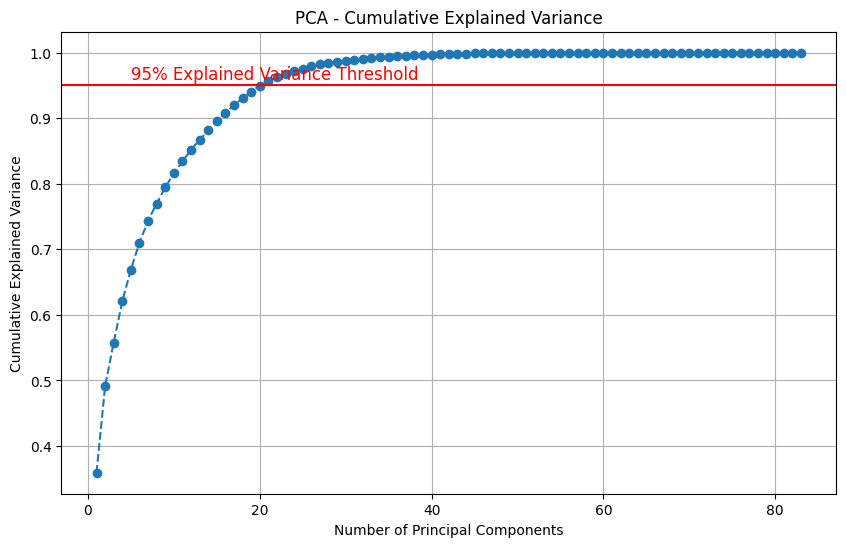

In [24]:
pca_full = PCA()
pca_full.fit(X_scaled_df)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot the explained variance to help you decide how many components to keep
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-') # 95% variance threshold line
plt.text(5, 0.96, '95% Explained Variance Threshold', color='red', fontsize=12)

plt.title('PCA - Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

## Applying PCA (Keeping 95% Variance)

In [25]:
pca_final = PCA(n_components=0.95) 

X_pca = pca_final.fit_transform(X_scaled_df)

print(f"Original number of features: {X_scaled_df.shape[1]}")
print(f"Number of components selected to retain 95% variance: {pca_final.n_components_}")

# Create the final DataFrame with the principal components
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

# Re-attach the label column if you had one
if target_column in df.columns:
    df_pca[target_column] = y.reset_index(drop=True)

display(df_pca.head())

Original number of features: 83
Number of components selected to retain 95% variance: 21


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,Class
0,2.774401,-0.108169,-1.149623,-0.662387,3.802285,-1.082224,-1.930077,-1.489255,1.058652,-0.512009,...,0.599982,-0.194452,-0.448902,-0.465683,0.427209,-0.790998,-0.029857,-0.626599,-0.378705,1
1,5.748490,-5.501019,-0.213084,-1.813291,0.834784,5.710056,0.717582,0.121907,-0.804488,1.450543,...,0.939416,-0.474633,0.465274,0.021044,1.123694,-0.267007,0.448807,1.473778,0.113049,1
2,-3.082195,-1.623650,2.037555,-3.367078,-0.734850,0.344368,-0.358741,-0.643964,0.078916,-0.056494,...,-0.001772,-0.365242,0.508196,0.059406,-0.294789,0.055980,-1.377611,-0.187201,0.319832,0
3,-3.350781,-1.555431,2.155344,-3.332080,-0.197623,0.636525,-0.366981,-0.226106,0.082427,-0.776947,...,-0.234909,-0.581181,-0.162637,0.339235,1.095331,-0.287378,1.034621,-0.109306,0.141775,1
4,10.487028,5.387298,2.063510,-0.562179,-0.231861,-1.772882,-1.426961,-0.972388,-2.001681,1.194006,...,-0.933397,-0.605069,0.833448,-0.679617,-0.451867,-0.173498,0.332630,-0.192323,0.142451,0


In [26]:
df_pca.to_csv("trojan_cleaned(pca).csv", index=False)

# Train Test Split

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('/kaggle/working/trojan_cleaned(scaled).csv')

X = df.drop(columns=['Class']) 
y = df['Class']

In [28]:
# First split: Train (70) + Temp (30)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, 
    y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

# Second split: Validation (15) + Test (15)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(124237, 83) (26622, 83) (26623, 83)


In [29]:
print(f"Total Dataset Size: {len(X)}")
print("---------------------------------")
print(f"X_train shape (70%): {X_train.shape}")
print(f"X_val shape   (15%): {X_val.shape}")
print(f"X_test shape  (15%): {X_test.shape}")

Total Dataset Size: 177482
---------------------------------
X_train shape (70%): (124237, 83)
X_val shape   (15%): (26622, 83)
X_test shape  (15%): (26623, 83)


# ****Implementation of DL Models****

In [30]:
#Reshape for LSTM & CNN

# Convert to numpy
X_train_np = X_train.values
X_val_np = X_val.values
X_test_np = X_test.values

# Reshape for sequence models
X_train_seq = X_train_np.reshape(-1, 83, 1)
X_val_seq = X_val_np.reshape(-1, 83, 1)
X_test_seq = X_test_np.reshape(-1, 83, 1)

In [31]:
#Common Training Setup

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# MLP+LSTM Model

In [32]:
# MLP branch
input_mlp = Input(shape=(83,))
x1 = Dense(128, activation='relu')(input_mlp)
x1 = Dropout(0.3)(x1)
x1 = Dense(64, activation='relu')(x1)

# LSTM branch
input_lstm = Input(shape=(83,1))
x2 = LSTM(64)(input_lstm)

# Fusion
combined = Concatenate()([x1, x2])
z = Dense(64, activation='relu')(combined)
z = Dropout(0.3)(z)
output = Dense(1, activation='sigmoid')(z)

model_lstm = Model(inputs=[input_mlp, input_lstm], outputs=output)

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

I0000 00:00:1777064913.517819      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777064913.523666      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 83)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     10,752 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 83, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     16,896 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 44,225 (172.75 KB)

 Trainable params: 44,225 (172.75 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history_lstm = model_lstm.fit(
    [X_train_np, X_train_seq], y_train,
    validation_data=([X_val_np, X_val_seq], y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


I0000 00:00:1777064917.989473     145 cuda_dnn.cc:529] Loaded cuDNN version 91002


3883/3883 ━━━━━━━━━━━━━━━━━━━━ 37s 9ms/step - accuracy: 0.5162 - loss: 14868.6201 - val_accuracy: 0.5432 - val_loss: 0.6875
Epoch 2/50
3883/3883 ━━━━━━━━━━━━━━━━━━━━ 33s 8ms/step - accuracy: 0.5486 - loss: 6.3022 - val_accuracy: 0.6488 - val_loss: 0.6058
Epoch 3/50
3883/3883 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - accuracy: 0.6447 - loss: 0.6124 - val_accuracy: 0.6897 - val_loss: 0.5634
Epoch 4/50
3883/3883 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - accuracy: 0.6682 - loss: 0.7655 - val_accuracy: 0.6791 - val_loss: 0.5580
Epoch 5/50
3883/3883 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - accuracy: 0.6798 - loss: 0.6211 - val_accuracy: 0.7012 - val_loss: 0.5379
Epoch 6/50
3883/3883 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - accuracy: 0.6916 - loss: 0.7600 - val_accuracy: 0.7081 - val_loss: 0.5326
Epoch 7/50
3883/3883 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - accuracy: 0.7119 - loss: 2.0178 - val_accuracy: 0.7198 - val_loss: 0.5092
Epoch 8/50
3883/3883 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - accuracy: 0.7210 - loss: 0.5963 -

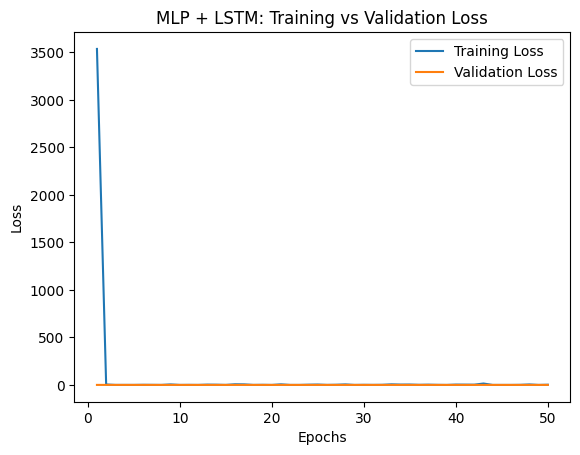

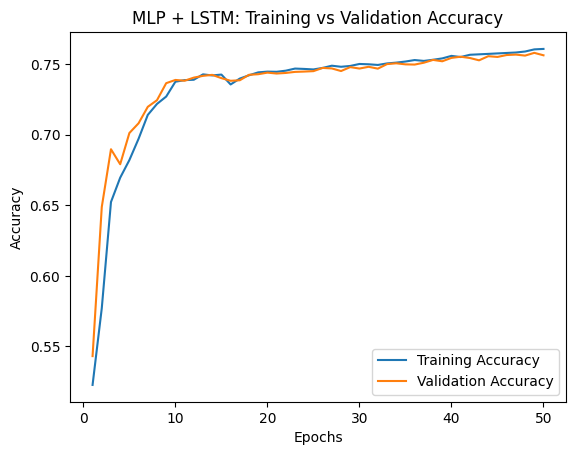

In [34]:
loss = history_lstm.history['loss']
val_loss = history_lstm.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('MLP + LSTM: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history_lstm.history['accuracy']
val_acc = history_lstm.history['val_accuracy']

epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('MLP + LSTM: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [35]:
y_pred_prob = model_lstm.predict([X_test_np, X_test_seq])
y_pred = (y_pred_prob > 0.5).astype(int)

print("MLP + LSTM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

832/832 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
MLP + LSTM Results:
Accuracy: 0.7614844307553619
Precision: 0.706508740960082
Recall: 0.9120782180401382
F1: 0.7962392504171479
ROC-AUC: 0.8468234366617196


In [36]:
model_lstm.save("trojan_lstm_cnn.keras")